# Microscope Model: Gaussian Beam Propagation

Load the microscope from TOML, build components for a chosen mode,
propagate Gaussian beams through the column, and visualise both the
ray trajectories and the detector-plane intensity.

In [6]:
import numpy as np
import jax.numpy as jnp
import matplotlib.pyplot as plt

from temgym_core.microscope_model import MicroscopeModel
from temgym_core.source import circular_input_wave
from temgym_core.components import SigmoidAperture, Detector
from temgym_core.run import run_to_end_vmapped, run_iter_vmapped
from temgym_core.evaluate import evaluate_gaussians_for

## 1. Load the model and choose an operating point

In [7]:
model = MicroscopeModel.from_toml(
    "microscope.toml",
    mode_names={
        "illumination.parallel": "spot",
        "imaging.magnification": "mag",
        "imaging.diffraction": "diff",
    },
    mode_defaults={"spot": {"Obj_prefield": 1.0}},
)

mode_name = "mag"
control_value = 100_000.0  # magnification

print(f"Voltage   : {model.voltage/1e3:.0f} kV")
print(f"Lenses    : {[l.name for l in model.lenses]}")
print(f"Deflectors: {[d.name for d in model.deflectors]}")
print(f"Modes     : {list(model.modes.keys())}")

Voltage   : 200 kV
Lenses    : ['CL1', 'CL3', 'C_mini', 'Obj_prefield', 'Obj_post', 'IL1', 'IL2', 'IL3', 'PL1']
Deflectors: ['CL12_deflector']
Modes     : ['spot', 'mag', 'diff']


## 2. Build the optical column

In [8]:
# Optical components from the mode tables
optics = list(model.build_components(mode_name, control_value))

# Aperture from the TOML auxiliary data
ap_info = model.auxiliary["apertures"]["C_aperture"]
aperture = SigmoidAperture(
    radius=ap_info["radii"][2],  # 30 um aperture
    edge_width=ap_info["radii"][2] * 0.05,
    sharpness=10.0,
    z=ap_info["z"],
)

# Detector from the TOML auxiliary data
det_info = model.auxiliary["detector"]
detector = Detector(
    z=det_info["z"],
    pixel_size=(det_info["pixel_size"], det_info["pixel_size"]),
    shape=(det_info["shape"][0], det_info["shape"][1]),
)

# Full column: optics + aperture + detector, sorted by z
column = sorted(optics + [aperture, detector], key=lambda c: float(c.z))

for c in column:
    print(f"  z = {float(c.z):.4f} m  {type(c).__name__}")

  z = 0.2000 m  ElectromagneticLens
  z = 0.2400 m  ElectromagneticLens
  z = 0.2500 m  SigmoidAperture
  z = 0.2900 m  DoubleDeflector
  z = 0.3000 m  ElectromagneticLens
  z = 0.3200 m  ElectromagneticLens
  z = 0.3273 m  ElectromagneticLens
  z = 0.5297 m  ElectromagneticLens
  z = 0.6068 m  ElectromagneticLens
  z = 0.6693 m  ElectromagneticLens
  z = 0.7214 m  ElectromagneticLens
  z = 0.8000 m  Detector


## 3. Create the input Gaussian beam

In [9]:
z_source = model.auxiliary.get("z_source", 0.0)
voltage = model.voltage

beam_in = circular_input_wave(
    aperture_radius=10e-9,  # 10 nm radius source
    waist=5e-9,             # 5 nm Gaussian waist
    voltage=voltage,
    z0=z_source,
)

n_rays = beam_in.x.shape[0]
print(f"Input beam: {n_rays} Gaussian sub-beams at z = {z_source} m")

Input beam: 51 Gaussian sub-beams at z = 0.0 m


/home/dl277493/Documents/Code/TemGymCore/src/temgym_core/gaussian.py:120: UserWarning: Explicitly requested dtype float64 requested in zeros is not available, and will be truncated to dtype float32. To enable more dtypes, set the jax_enable_x64 configuration option or the JAX_ENABLE_X64 shell environment variable. See https://github.com/jax-ml/jax#current-gotchas for more.
  Q_inv_re = jnp.zeros((n_rays, 2, 2), dtype=jnp.float64)
/home/dl277493/Documents/Code/TemGymCore/src/temgym_core/gaussian.py:124: UserWarning: Explicitly requested dtype float64 requested in zeros is not available, and will be truncated to dtype float32. To enable more dtypes, set the jax_enable_x64 configuration option or the JAX_ENABLE_X64 shell environment variable. See https://github.com/jax-ml/jax#current-gotchas for more.
  Q_inv_im = jnp.zeros((n_rays, 2, 2), dtype=jnp.float64)
/nobackup/dl277493/temgym_core/lib/python3.12/site-packages/jax/_src/numpy/array_methods.py:125: UserWarning: Explicitly requested d

## 4. Propagate and collect ray trajectories

In [10]:
def trace_column(beam, components):
    """Propagate beam through components, recording (z, x) at each step.

    Uses jax.vmap internally so each component sees a single ray.
    """
    zs = [float(beam.z[0])]
    xs = [np.array(beam.x)]

    # run_iter_vmapped returns a tuple of Ray, one per propagation/component step
    step_rays = run_iter_vmapped(beam, components)
    for ray in step_rays:
        zs.append(float(ray.z[0]))
        xs.append(np.array(ray.x))

    beam_out = step_rays[-1]
    return np.array(zs), np.stack(xs, axis=0), beam_out


zs, xs, beam_out = trace_column(beam_in, column)
print(f"Traced {len(zs)} steps, final z = {zs[-1]:.4f} m")

/home/dl277493/Documents/Code/TemGymCore/src/temgym_core/ray.py:108: UserWarning: Explicitly requested dtype float64 requested in asarray is not available, and will be truncated to dtype float32. To enable more dtypes, set the jax_enable_x64 configuration option or the JAX_ENABLE_X64 shell environment variable. See https://github.com/jax-ml/jax#current-gotchas for more.
  dx = jnp.asarray(self.dx, dtype=jnp.float64)
/home/dl277493/Documents/Code/TemGymCore/src/temgym_core/ray.py:109: UserWarning: Explicitly requested dtype float64 requested in asarray is not available, and will be truncated to dtype float32. To enable more dtypes, set the jax_enable_x64 configuration option or the JAX_ENABLE_X64 shell environment variable. See https://github.com/jax-ml/jax#current-gotchas for more.
  dy = jnp.asarray(self.dy, dtype=jnp.float64)
/nobackup/dl277493/temgym_core/lib/python3.12/site-packages/jax/_src/numpy/lax_numpy.py:5816: UserWarning: Explicitly requested dtype complex128 requested in ey

Traced 25 steps, final z = 0.8000 m


## 5. Ray trajectory plot

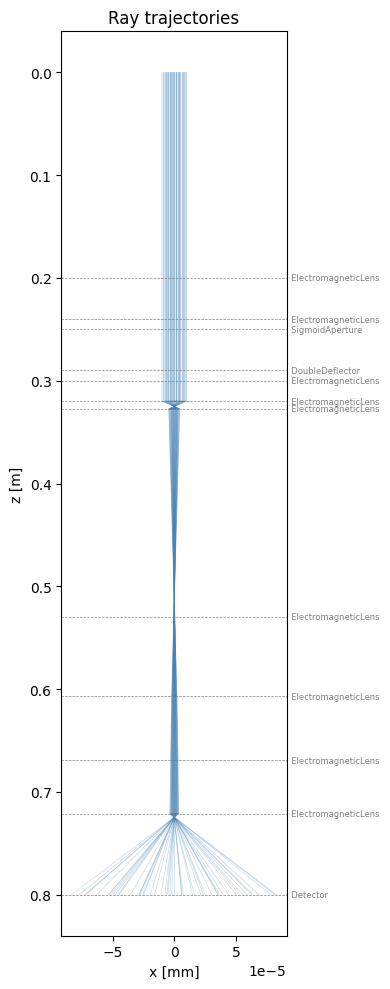

In [11]:
def plot_column(zs, xs, components, max_rays=50, ax=None):
    """Minimal ray trajectory visualisation along the column."""
    if ax is None:
        fig, ax = plt.subplots(figsize=(4, 10))

    # Plot ray lines (subsample if many)
    n_rays = xs.shape[1]
    stride = max(1, n_rays // max_rays)
    for j in range(0, n_rays, stride):
        ax.plot(xs[:, j] * 1e3, zs, color="steelblue", alpha=0.3, lw=0.5)

    # Mark components
    for c in components:
        z_c = float(c.z)
        label = type(c).__name__
        if hasattr(c, 'name'):
            label = getattr(c, 'name', label)
        ax.axhline(z_c, color="gray", ls="--", lw=0.5)
        ax.text(
            ax.get_xlim()[1], z_c, f"  {label}",
            va="center", fontsize=6, color="gray",
        )

    ax.set_xlabel("x [mm]")
    ax.set_ylabel("z [m]")
    ax.invert_yaxis()
    ax.set_title("Ray trajectories")
    plt.tight_layout()
    return ax


plot_column(zs, xs, column);

## 6. Evaluate Gaussian intensity at the detector

/home/dl277493/Documents/Code/TemGymCore/src/temgym_core/evaluate.py:290: UserWarning: Explicitly requested dtype float64 requested in asarray is not available, and will be truncated to dtype float32. To enable more dtypes, set the jax_enable_x64 configuration option or the JAX_ENABLE_X64 shell environment variable. See https://github.com/jax-ml/jax#current-gotchas for more.
  x = jnp.asarray(x, dtype=dtype)
/home/dl277493/Documents/Code/TemGymCore/src/temgym_core/evaluate.py:290: UserWarning: Explicitly requested dtype complex128 requested in asarray is not available, and will be truncated to dtype complex64. To enable more dtypes, set the jax_enable_x64 configuration option or the JAX_ENABLE_X64 shell environment variable. See https://github.com/jax-ml/jax#current-gotchas for more.
  x = jnp.asarray(x, dtype=dtype)
/home/dl277493/Documents/Code/TemGymCore/src/temgym_core/evaluate.py:379: UserWarning: Explicitly requested dtype complex128 requested in zeros is not available, and will 

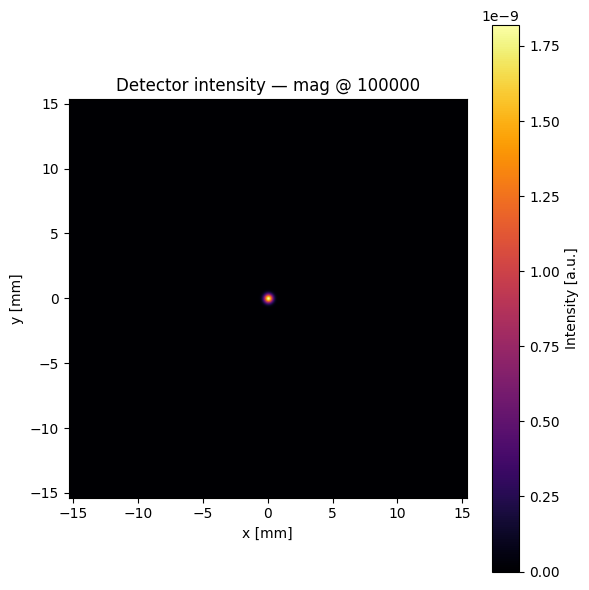

In [12]:
field = evaluate_gaussians_for(beam_out, detector)
intensity = jnp.abs(field) ** 2

extent_mm = (
    np.array([
        -det_info["shape"][1] / 2,
         det_info["shape"][1] / 2,
        -det_info["shape"][0] / 2,
         det_info["shape"][0] / 2,
    ])
    * det_info["pixel_size"]
    * 1e3  # to mm
)

fig, ax = plt.subplots(figsize=(6, 6))
im = ax.imshow(
    np.array(intensity),
    extent=extent_mm,
    origin="lower",
    cmap="inferno",
)
ax.set_xlabel("x [mm]")
ax.set_ylabel("y [mm]")
ax.set_title(f"Detector intensity — {mode_name} @ {control_value:.0f}")
fig.colorbar(im, ax=ax, label="Intensity [a.u.]")
plt.tight_layout();